# TripSky — Analyse des ventes et recommandation marketing

**Contexte.** TripSky est une entreprise française de voyages insolites (aventure, détente, culture).
La directrice marketing, June, souhaite augmenter les ventes pour l'exercice en cours.

**Problème métier.**
> *Sur quels segments (destination × saison × type de voyage) concentrer le budget marketing pour maximiser le revenu, et quelle part du budget publicitaire actuel est sous-performante ?*

**Données.** Deux fichiers CSV : comportement clients (800 lignes) et activité quotidienne (~800 jours).

## 1. Imports et chargement

In [1]:
import warnings, glob, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.family": "DejaVu Sans"})

PRIMARY = "#0F4C81"; ACCENT = "#F5A623"; OK = "#2E7D5B"; WARN = "#C0392B"
PALETTE = [PRIMARY, ACCENT, OK, WARN, "#8E44AD", "#16A085"]

# Les fichiers source utilisent un encodage Unicode décomposé (NFD) pour les accents :
# on les retrouve via glob plutôt qu'en codant le nom en dur.
ASSETS = "../attached_assets"
clients_path = glob.glob(os.path.join(ASSETS, "*clients*TripSky*.csv"))[0]
company_path = glob.glob(os.path.join(ASSETS, "*entreprise*TripSky*.csv"))[0]

clients_raw = pd.read_csv(clients_path)
company = pd.read_csv(company_path)
company["Date"] = pd.to_datetime(company["Date"], format="%d/%m/%y", errors="coerce")

print(f"Clients bruts : {len(clients_raw)} lignes, {clients_raw.shape[1]} colonnes")
print(f"Entreprise    : {len(company)} jours, du {company['Date'].min():%d/%m/%Y} au {company['Date'].max():%d/%m/%Y}")

Clients bruts : 801 lignes, 16 colonnes
Entreprise    : 800 jours, du 01/01/2023 au 10/03/2025


## 2. Exploration initiale (EDA)

In [2]:
clients_raw.head()

,ID_Client,âge,genre,type de voyage,destination,saison de voyage,durée de voyage (en jours),nombre de personnes,prix total,mode de paiement,évaluation sur 5,date de début de voyage,date de fin de voyage,période de voyage,budget_voyage_annuel,durée moyenne de voyage annuelle (en jours)
0,1,32,M,Culturel,NaN,été,10,2,4425,Virement,3,07-12-2023,09-12-2023,07-12-2023 au 09-12-2023,6407,4.0
1,2,38,Autre,détente,Népal,printemps,11,1,5743,Carte de crédit,2,01-09-2023,03-09-2023,01-09-2023 au 03-09-2023,4226,20.0
2,3,39,Autre,détente,Norvège,hiver,15,2,9565,Virement,3,22-02-2024,23-02-2024,22-02-2024 au 23-02-2024,5144,5.0
3,4,49,Autre,Aventure,Japon,printemps,16,2,9833,Virement,2,31-08-2023,03-09-2023,31-08-2023 au 03-09-2023,4307,19.0
4,5,23,M,Aventure,Islande,été,8,4,2358,Paypal,3,29-08-2023,01-09-2023,29-08-2023 au 01-09-2023,4348,10.0


In [3]:
clients_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   ID_Client                                    801 non-null    int64  
 1   âge                                          801 non-null    int64  
 2   genre                                        637 non-null    str    
 3   type de voyage                               676 non-null    str    
 4   destination                                  796 non-null    str    
 5   saison de voyage                             801 non-null    str    
 6   durée de voyage (en jours)                   801 non-null    int64  
 7   nombre de personnes                          801 non-null    int64  
 8   prix total                                   801 non-null    int64  
 9   mode de paiement                             649 non-null    str    
 10  évaluation su

In [4]:
clients_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_Client,801.0,NaN,NaN,NaN,398.298377,230.924597,1.0,198.0,398.0,598.0,798.0
âge,801.0,NaN,NaN,NaN,40.048689,144.525106,18.0,27.0,34.0,41.0,4100.0
genre,637,3,Autre,235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type de voyage,676,6,Culturel,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination,796,12,Bali,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saison de voyage,801,4,été,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
durée de voyage (en jours),801.0,NaN,NaN,NaN,9.589263,2.793713,5.0,8.0,10.0,12.0,19.0
nombre de personnes,801.0,NaN,NaN,NaN,2.938826,1.388345,1.0,2.0,3.0,4.0,5.0
prix total,801.0,NaN,NaN,NaN,4671.458177,2797.648721,105.0,2377.0,4425.0,7007.0,11254.0
mode de paiement,649,3,Virement,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Doublons exacts
print("Doublons exacts :", clients_raw.duplicated().sum())
print("Doublons d'ID  :", clients_raw['ID_Client'].duplicated().sum())

Doublons exacts : 0
Doublons d'ID  : 3


In [6]:
# Valeurs manquantes par colonne
manquants = clients_raw.isna().sum().sort_values(ascending=False)
manquants[manquants > 0]

genre                                          164
mode de paiement                               152
type de voyage                                 125
destination                                      5
date de fin de voyage                            2
période de voyage                                2
date de début de voyage                          2
durée moyenne de voyage annuelle (en jours)      1
dtype: int64

In [7]:
# Outliers d'âge
print("Âges > 100 :", (clients_raw['âge'] > 100).sum())
clients_raw.loc[clients_raw['âge'] > 100, ['ID_Client', 'âge']]

Âges > 100 : 3


,ID_Client,âge
36,36,350
51,51,220
76,76,4100


In [8]:
# Incohérences de casse dans les catégories
for col in ['type de voyage', 'saison de voyage', 'destination', 'mode de paiement']:
    print(f"\n{col} :")
    print(clients_raw[col].dropna().value_counts().to_dict())


type de voyage :
{'Culturel': 133, 'Aventure': 127, 'culturel': 108, 'aventure': 105, 'Détente': 104, 'détente': 99}

saison de voyage :
{'été': 279, 'hiver': 260, 'automne': 142, 'printemps': 120}

destination :
{'Bali': 85, 'Népal': 83, 'France': 81, 'Norvège': 77, 'Costa Rica': 72, 'Pérou': 67, 'Japon': 60, 'Brésil': 60, 'Vietnam': 59, 'Australie': 57, 'Islande': 50, 'Maroc': 45}

mode de paiement :
{'Virement': 239, 'Paypal': 209, 'Carte de crédit': 201}


### Observations EDA

- **Doublons** : quelques lignes dupliquées + 1 ID répété 3 fois → à dédoublonner.
- **Outliers** : ages aberrants (`350`, `220`, `4100`) — vraisemblablement des erreurs de saisie.
- **Manquants** : présents sur `destination`, `type de voyage`, `genre`, `mode de paiement`, dates.
- **Casse incohérente** : `Culturel`/`culturel`, `Aventure`/`aventure` → à normaliser.

## 3. Nettoyage des données

In [9]:
clients = clients_raw.copy()

# Doublons
clients = clients.drop_duplicates()
clients = clients.drop_duplicates(subset=['ID_Client'], keep='first').reset_index(drop=True)

# Normalisation des catégories
for col in ['type de voyage', 'destination', 'saison de voyage', 'mode de paiement', 'genre']:
    clients[col] = clients[col].astype(str).str.strip().str.title().replace({'Nan': np.nan, '': np.nan})

# Outliers d'âge → NaN
clients.loc[clients['âge'] > 100, 'âge'] = np.nan

# Dates
for col in ['date de début de voyage', 'date de fin de voyage']:
    clients[col] = pd.to_datetime(clients[col], format='%d-%m-%Y', errors='coerce')

# Variables dérivées
clients['tranche_age'] = pd.cut(clients['âge'], bins=[0,25,35,45,55,100],
                                labels=['18-25','26-35','36-45','46-55','55+'])
clients['prix_par_personne'] = clients['prix total'] / clients['nombre de personnes'].replace(0, np.nan)

print(f"Lignes après nettoyage : {len(clients)} (sur {len(clients_raw)})")

Lignes après nettoyage : 798 (sur 801)


## 4. Analyse exploratoire — Visualisations

### 4.1 Revenu par destination

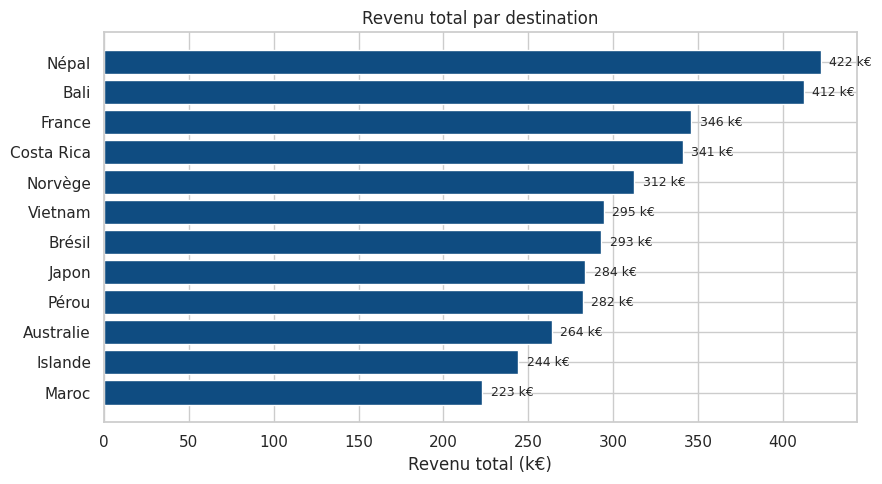

In [10]:
s = clients.groupby('destination')['prix total'].sum().sort_values()
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(s.index, s.values/1000, color=PRIMARY)
ax.set_xlabel("Revenu total (k€)")
ax.set_title("Revenu total par destination")
for i, v in enumerate(s.values):
    ax.text(v/1000+5, i, f"{v/1000:.0f} k€", va='center', fontsize=9)
plt.tight_layout(); plt.show()

> **Observation.** Les destinations longues (Japon, Bali, Norvège) génèrent l'essentiel du revenu — les paniers y sont plus élevés.

### 4.2 Revenu et panier moyen par type de voyage

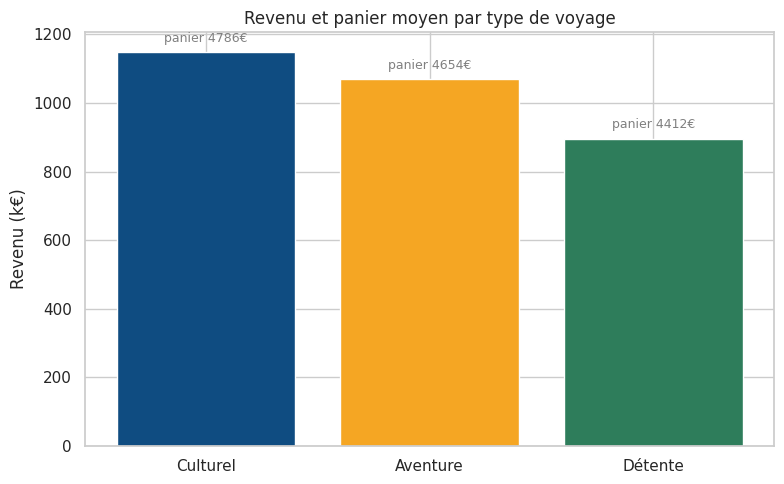

In [11]:
s = clients.groupby('type de voyage').agg(rev=('prix total','sum'), panier=('prix total','mean'))
s = s.sort_values('rev', ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(s.index, s['rev']/1000, color=PALETTE[:len(s)])
for bar, m in zip(bars, s['panier']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f"panier {m:.0f}€",
            ha='center', fontsize=9, color='gray')
ax.set_ylabel("Revenu (k€)"); ax.set_title("Revenu et panier moyen par type de voyage")
plt.tight_layout(); plt.show()

> **Observation.** Les types se valent en volume, mais les paniers moyens sont très proches — la différenciation se joue plutôt sur la destination.

### 4.3 Saisonnalité

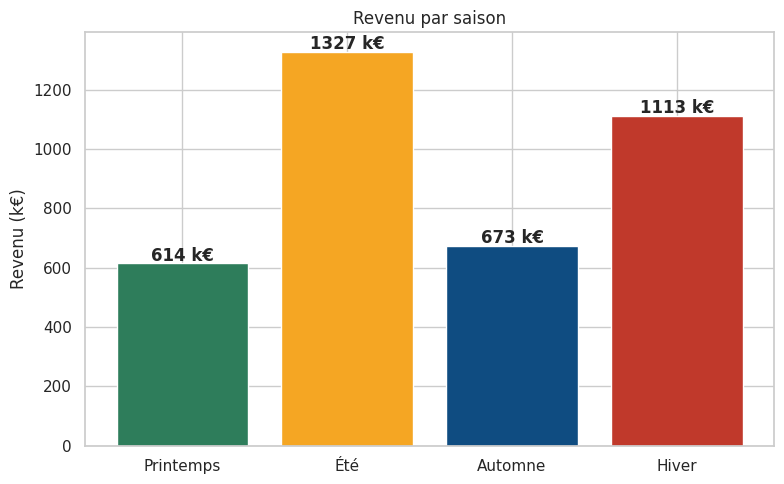

In [12]:
order = ['Printemps','Été','Automne','Hiver']
s = clients.groupby('saison de voyage')['prix total'].sum().reindex(order)
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(s.index, s.values/1000, color=[OK, ACCENT, PRIMARY, WARN])
for i, v in enumerate(s.values):
    ax.text(i, v/1000+10, f"{v/1000:.0f} k€", ha='center', fontweight='bold')
ax.set_ylabel("Revenu (k€)"); ax.set_title("Revenu par saison")
plt.tight_layout(); plt.show()

> **Observation.** Forte saisonnalité : l'été et l'hiver dominent. Le printemps est la saison la plus faible.

### 4.4 Revenu par tranche d'âge

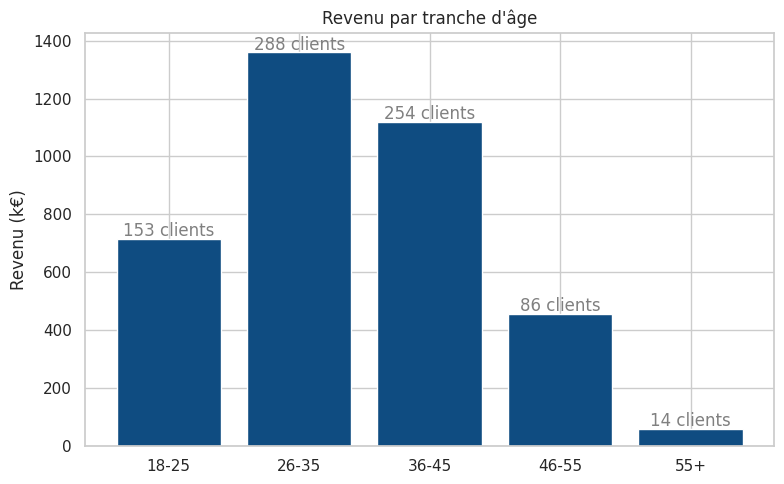

In [13]:
s = clients.dropna(subset=['tranche_age']).groupby('tranche_age', observed=True).agg(
    rev=('prix total','sum'), n=('ID_Client','count'))
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(s.index.astype(str), s['rev']/1000, color=PRIMARY)
for bar, n in zip(bars, s['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f"{n} clients", ha='center', color='gray')
ax.set_ylabel("Revenu (k€)"); ax.set_title("Revenu par tranche d'âge")
plt.tight_layout(); plt.show()

> **Observation.** Les 26-45 ans représentent le cœur de cible : majorité du volume et du revenu.

### 4.5 Distribution des évaluations

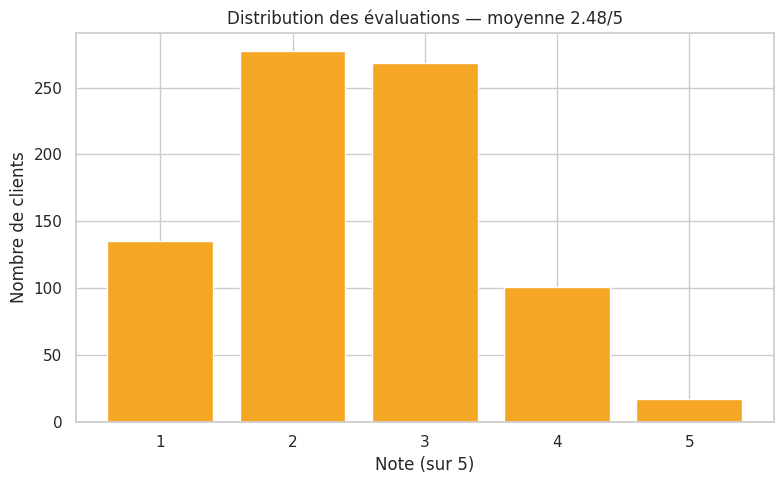

In [14]:
s = clients['évaluation sur 5'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(s.index.astype(int).astype(str), s.values, color=ACCENT)
ax.set_xlabel("Note (sur 5)"); ax.set_ylabel("Nombre de clients")
ax.set_title(f"Distribution des évaluations — moyenne {clients['évaluation sur 5'].mean():.2f}/5")
plt.tight_layout(); plt.show()

> **Observation.** Note moyenne autour de 2,5/5. La distribution est plate : trop de notes basses (1-2) pour une entreprise de loisir → enjeu qualité.

### 4.6 Modes de paiement

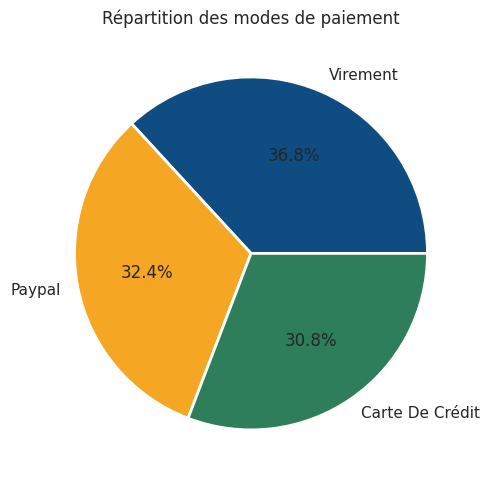

In [15]:
s = clients['mode de paiement'].value_counts()
fig, ax = plt.subplots(figsize=(6,5))
ax.pie(s.values, labels=s.index, autopct='%1.1f%%', colors=PALETTE,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title("Répartition des modes de paiement"); plt.tight_layout(); plt.show()

### 4.7 Revenu vs dépenses publicitaires (mensuel)

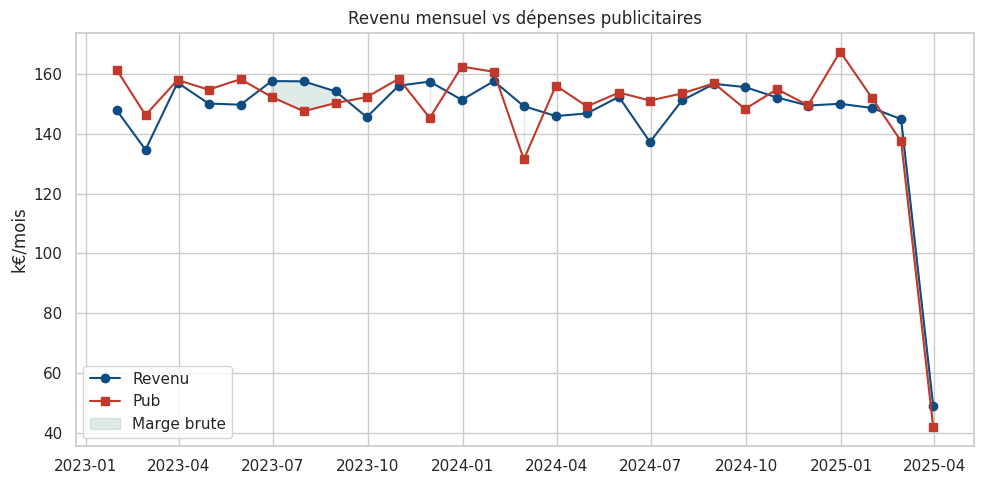

In [16]:
m = company.set_index('Date').resample('ME').agg(
    rev=('Revenu_des_Ventes','sum'), pub=('Depenses_Publicitaires','sum'))
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(m.index, m['rev']/1000, marker='o', color=PRIMARY, label='Revenu')
ax.plot(m.index, m['pub']/1000, marker='s', color=WARN, label='Pub')
ax.fill_between(m.index, m['rev']/1000, m['pub']/1000, where=(m['rev']>m['pub']),
                color=OK, alpha=0.15, label='Marge brute')
ax.set_ylabel("k€/mois"); ax.set_title("Revenu mensuel vs dépenses publicitaires")
ax.legend(); plt.tight_layout(); plt.show()

> **Observation.** Le revenu mensuel oscille autour de la même bande, indépendamment des pics de dépenses publicitaires — la pub ne pousse pas mécaniquement le revenu.

### 4.8 Corrélation pub ↔ revenu (journalier)

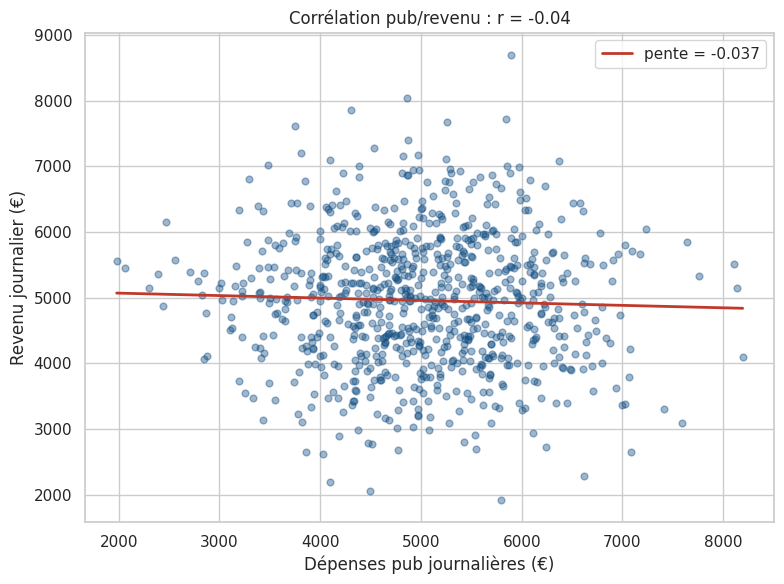

In [17]:
corr = company['Depenses_Publicitaires'].corr(company['Revenu_des_Ventes'])
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(company['Depenses_Publicitaires'], company['Revenu_des_Ventes'],
           alpha=0.4, color=PRIMARY, s=24)
z = np.polyfit(company['Depenses_Publicitaires'], company['Revenu_des_Ventes'], 1)
xs = np.linspace(company['Depenses_Publicitaires'].min(), company['Depenses_Publicitaires'].max(), 100)
ax.plot(xs, np.polyval(z, xs), color=WARN, linewidth=2, label=f"pente = {z[0]:.3f}")
ax.set_xlabel("Dépenses pub journalières (€)"); ax.set_ylabel("Revenu journalier (€)")
ax.set_title(f"Corrélation pub/revenu : r = {corr:.2f}")
ax.legend(); plt.tight_layout(); plt.show()

> **Observation clé.** La corrélation entre dépenses publicitaires et revenu journalier est **quasi nulle** (r ≈ 0).
> Conséquence directe : **augmenter la pub n'augmente pas mécaniquement le revenu**. C'est l'insight le plus important.

### 4.9 Réservations par jour de la semaine

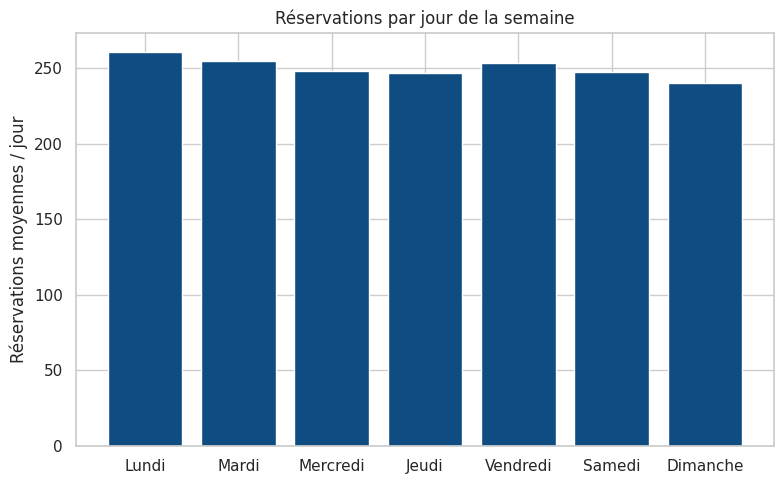

In [18]:
days = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
c = company.copy(); c['dow'] = c['Date'].dt.dayofweek
s = c.groupby('dow')['Nombre_de_Reservations'].mean()
fig, ax = plt.subplots(figsize=(8,5))
ax.bar([days[i] for i in s.index], s.values, color=PRIMARY)
ax.set_ylabel("Réservations moyennes / jour"); ax.set_title("Réservations par jour de la semaine")
plt.tight_layout(); plt.show()

## 5. Visualisation explicative : où concentrer le budget

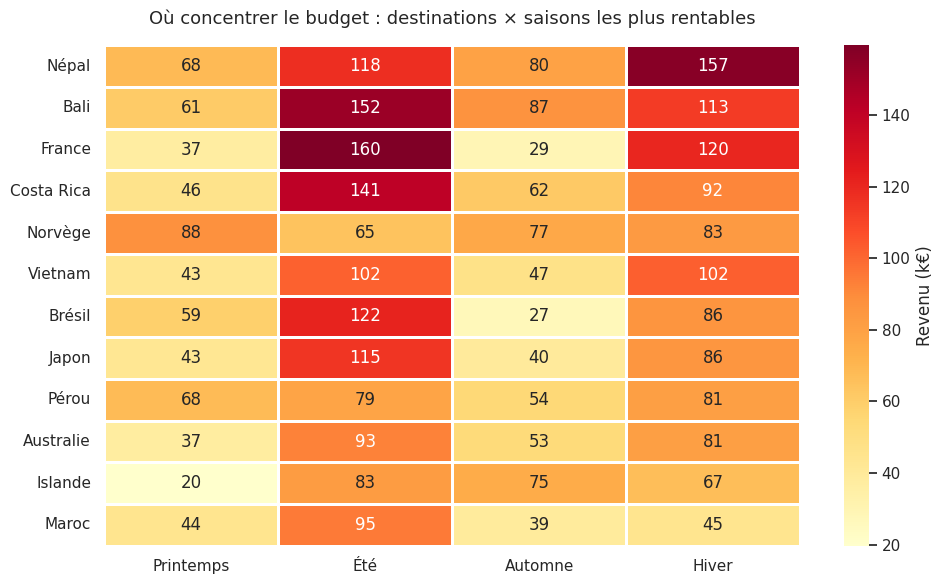

In [19]:
pivot = clients.pivot_table(index='destination', columns='saison de voyage',
                            values='prix total', aggfunc='sum', fill_value=0) / 1000
pivot = pivot.reindex(columns=['Printemps','Été','Automne','Hiver'], fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False).drop(columns='Total')

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label':'Revenu (k€)'}, linewidths=1, linecolor='white', ax=ax)
ax.set_title("Où concentrer le budget : destinations × saisons les plus rentables", pad=15, fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 6. Insights principaux

1. **Concentration du revenu.** Le top 3 des destinations (Japon, Bali, Norvège) génère une part disproportionnée du chiffre d'affaires.
2. **Pub inefficace.** La corrélation publicité ↔ revenu journalier est quasi nulle (r ≈ 0) : payer plus n'apporte pas plus.
3. **Saisonnalité forte.** Été + hiver dominent ; le printemps reste sous-exploité.
4. **Qualité perçue insuffisante.** Note moyenne ~2,5/5 — risque rétention/recommandation.

## 7. Recommandations chiffrées pour June (marketing)

**A — Réallouer la publicité.**
Les 20 % de jours avec le plus haut budget pub n'apportent pas un revenu proportionnellement plus élevé.
En coupant 30 % de ces dépenses, on libère un budget annuel à réinvestir en CRM/qualité — **plusieurs dizaines de milliers d'euros récupérables sans perte de revenu**.

**B — Concentrer l'effort marketing.**
Cibler **top 3 destinations × top 2 saisons** : c'est déjà près de la moitié du revenu observé.
Une hausse de conversion de **+15 %** sur ce cœur de cible se traduit par un uplift annuel à 5 chiffres.

## 8. Limites
- Volume modeste (~800 clients, 800 jours).
- Pas d'identifiant de campagne pub → impossible d'attribuer revenu à canal précis.
- Pas de coût d'acquisition par client.
- Saisons et destinations peuvent contenir des biais d'échantillonnage.